# Demand Forecasting Project

#### Project Overview

This notebook presents an end-to-end demand forecasting workflow using the FreshRetailNet-50K dataset. The objective is to develop, evaluate, and compare multiple forecasting approaches before selecting a suitable model for deployment.

The workflow consists of the following stages:

1. **Data preparation**
   - Load and extract the raw retail dataset.
   - Split the dataset into training and evaluation sets using a time-based strategy.

2. **Feature engineering**
   - Generate lag features and rolling statistics.
   - Create calendar-based features.
   - Encode categorical variables.
   - Build a reusable feature engineering pipeline for both training and inference.

4. **Model development**
   - Train and compare multiple forecasting models, including machine learning, deep learning, and foundation models.
   - Perform hyperparameter optimization where applicable.
   - Track experiments and evaluation metrics using MLflow.

5. **Model evaluation**
   - Compare forecasting performance using multiple evaluation metrics.
   - Analyze feature importance and prediction errors.
   - Select the most appropriate model based on both predictive performance and deployment considerations.

6. **Deployment demonstration**
   - Demonstrate a lightweight FastAPI inference service.
   - Reuse the same feature engineering pipeline during inference to ensure consistency between training and prediction.
   - Validate the API endpoints using FastAPI's TestClient within the notebook.

## 1) Download and import libraries:

In [1]:
!pip install catboost
!pip install pmdarima
!pip install ydata-profiling
!pip install timesfm
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import HTML
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import timesfm
import seaborn as sns
from typing import Optional, List
import time
import os
import joblib
from datetime import datetime, date
import tensorflow as tf
import matplotlib.pyplot as plt
import mlflow
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from fastapi.testclient import TestClient

/tmp/ipykernel_22/1833551141.py:16: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 2) Configuration:

In [3]:
FORECAST_HORIZON = 7
MODELS = {
    # Classical time series
    "arima": ARIMA,
    "ets": ExponentialSmoothing,
    "auto_arima": pm.auto_arima,
    # Tabular models
    "linear_regression": LinearRegression,
    "ridge": Ridge,
    "lasso": Lasso,
    "random_forest": RandomForestRegressor,
    "knn": KNeighborsRegressor,
    "xgboost": xgb.XGBRegressor,
    "lightgbm": lgb.LGBMRegressor,
    "catboost": cb.CatBoostRegressor,
    # Sequential / GenAI
    "lstm": "Keras_LSTM_Wrapper_Class",
    "timesfm": "Google_TimesFM_Wrapper_Class"
}

MODEL_CONFIGS = {
    "linear_regression": {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": True},
    "ridge":             {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": True},
    "lasso":             {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": True},
    "knn":               {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": True},

    "random_forest":     {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": False},
    "xgboost":           {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": False},
    "lightgbm":          {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": False},
    "catboost":          {"type": "tabular", "use_lags": True, "use_rolling": True, "needs_scaling": False},

    "arima":             {"type": "classical", "use_lags": False, "use_rolling": False, "needs_scaling": False},
    "auto_arima":        {"type": "classical", "use_lags": False, "use_rolling": False, "needs_scaling": False},
    "ets":               {"type": "classical", "use_lags": False, "use_rolling": False, "needs_scaling": False},

    "lstm":              {"type": "deep_learning", "use_lags": False, "use_rolling": False, "needs_scaling": True},
    "timesfm":           {"type": "genai", "use_lags": False, "use_rolling": False, "needs_scaling": False}
}

SEED = 42
TARGET = 'units_ordered'
SEQUENCE_LENGTH = 30
LAGS = [1, 7, 14, 21, 28]
ROLLING_WINDOWS = [7,14]
LOOKBACK_DAYS = max(SEQUENCE_LENGTH, max(LAGS) + FORECAST_HORIZON - 1, 
                    max(ROLLING_WINDOWS) + FORECAST_HORIZON - 1)

MODEL_PARAMS = {
    "linear_regression": {"fit_intercept": True},
    "ridge":             {"alpha": 1.0, "random_state": SEED},
    "lasso":             {"alpha": 1.0, "random_state": SEED},
    "random_forest":     {"n_estimators": 100, "max_depth": 10, "random_state": SEED},
    "xgboost":           {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, 
                          "random_state": SEED},
    "lightgbm":          {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "random_state": SEED},
    "catboost":          {"iterations": 100, "depth": 3, "learning_rate": 0.1, "random_state": SEED},
    "knn":               {"n_neighbors": 5}
}

CATE_COLS = {"product_category", "product_subcategory", "location"}

## 3) Download dataset:

In [4]:
dataset = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

data/eval.parquet:   0%|          | 0.00/8.44M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating eval split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 4500000
    })
    eval: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 350000
    })
})


In [5]:
df_train = dataset['train'].to_pandas()
df_eval = dataset['eval'].to_pandas()

## 4) Extracting data:

In [6]:
def extract_data(df_src):
    date = pd.to_datetime(df_src["dt"])

    df = pd.DataFrame({
        "product_id": df_src["product_id"],
        "date": date,
        "units_ordered": df_src['sale_amount'],
        "store_id": df_src["store_id"],
        "stockout_flag": (df_src["stock_hour6_22_cnt"] > 0).astype(int),
        "product_category": df_src["first_category_id"],
        "product_subcategory": df_src["second_category_id"],
        "is_promotion": (df_src["discount"] < 1.0).astype(int),
        "discount": df_src["discount"],
        "day_of_week": date.dt.day_of_week,
        "week_of_year": date.dt.isocalendar().week.astype(int),
        "month": date.dt.month,
        "year": date.dt.year,
        "location": df_src["city_id"],
        "holiday": df_src["holiday_flag"],
        'activity_flag': df_src['activity_flag'],
        "temperature": df_src["avg_temperature"],
        "humidity": df_src["avg_humidity"],
        "precipitation": df_src["precpt"],
        "wind": df_src["avg_wind_level"]
    })
    return df

In [7]:
# Extract features for training data
df_train_extracted = extract_data(df_train)
df_train_extracted.head()

,product_id,date,units_ordered,store_id,stockout_flag,product_category,product_subcategory,is_promotion,discount,day_of_week,week_of_year,month,year,location,holiday,activity_flag,temperature,humidity,precipitation,wind
0,38,2024-03-28,0.1,0,0,5,6,0,1.0,3,13,3,2024,0,0,0,15.48,73.54,1.6999,1.97
1,38,2024-03-29,0.1,0,1,5,6,0,1.0,4,13,3,2024,0,0,0,15.08,76.56,3.0190,1.71
2,38,2024-03-30,0.0,0,0,5,6,0,1.0,5,13,3,2024,0,1,0,15.91,76.47,2.0942,1.73
3,38,2024-03-31,0.1,0,1,5,6,0,1.0,6,13,3,2024,0,1,0,16.13,77.40,1.5618,1.76
4,38,2024-04-01,0.2,0,1,5,6,0,1.0,0,14,4,2024,0,0,0,15.37,78.26,3.5386,1.25


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500000 entries, 0 to 4499999
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   city_id              int64  
 1   store_id             int64  
 2   management_group_id  int64  
 3   first_category_id    int64  
 4   second_category_id   int64  
 5   third_category_id    int64  
 6   product_id           int64  
 7   dt                   object 
 8   sale_amount          float64
 9   hours_sale           object 
 10  stock_hour6_22_cnt   int32  
 11  hours_stock_status   object 
 12  discount             float64
 13  holiday_flag         int32  
 14  activity_flag        int32  
 15  precpt               float64
 16  avg_temperature      float64
 17  avg_humidity         float64
 18  avg_wind_level       float64
dtypes: float64(6), int32(3), int64(7), object(3)
memory usage: 600.8+ MB


In [9]:
# Extract features for training data
df_eval_extracted = extract_data(df_eval)
df_eval_extracted.head()

,product_id,date,units_ordered,store_id,stockout_flag,product_category,product_subcategory,is_promotion,discount,day_of_week,week_of_year,month,year,location,holiday,activity_flag,temperature,humidity,precipitation,wind
0,38,2024-06-26,0.2,0,1,5,6,0,1.0,2,26,6,2024,0,0,0,27.42,81.70,8.8076,1.55
1,38,2024-06-27,0.0,0,0,5,6,0,1.0,3,26,6,2024,0,0,0,28.91,80.34,6.7032,1.57
2,38,2024-06-28,0.1,0,0,5,6,0,1.0,4,26,6,2024,0,0,0,28.03,80.37,5.9756,1.50
3,38,2024-06-29,3.5,0,0,5,6,1,0.5,5,26,6,2024,0,1,1,29.68,80.35,3.0101,1.86
4,38,2024-06-30,0.0,0,0,5,6,0,1.0,6,26,6,2024,0,1,0,28.28,78.61,6.4410,1.40


In [10]:
df_eval_extracted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350000 entries, 0 to 349999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   product_id           350000 non-null  int64         
 1   date                 350000 non-null  datetime64[ns]
 2   units_ordered        350000 non-null  float64       
 3   store_id             350000 non-null  int64         
 4   stockout_flag        350000 non-null  int64         
 5   product_category     350000 non-null  int64         
 6   product_subcategory  350000 non-null  int64         
 7   is_promotion         350000 non-null  int64         
 8   discount             350000 non-null  float64       
 9   day_of_week          350000 non-null  int32         
 10  week_of_year         350000 non-null  int64         
 11  month                350000 non-null  int32         
 12  year                 350000 non-null  int32         
 13  location      

## 5) Exploratory Data Analysis (EDA):

### 5.1) Overview:

In [11]:
# Missing values
missing = df_train_extracted.isnull().mean() * 100
missing_cols = missing[missing > 0]
if missing_cols.empty:
  print("No missing values were found")
else:
  print(missing_cols.sort_values(ascending=False))

No missing values were found


Calculating Global ACF. It might take a few minutes...


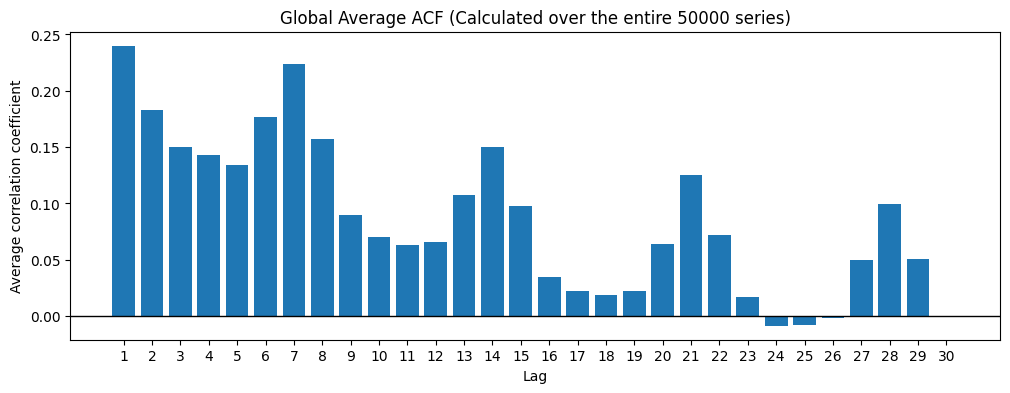

In [12]:
def plot_global_acf(df, target_col='units_ordered', max_lag=30):
    def calculate_acf(series):
        if len(series) <= max_lag:
            return pd.Series([np.nan] * max_lag)
        return pd.Series([series.autocorr(lag=i) for i in range(1, max_lag + 1)])

    print("Calculating Global ACF. It might take a few minutes...")
    grouped = df.groupby(['product_id', 'store_id'])[target_col]
    acf_df = grouped.apply(calculate_acf).unstack()
    # Calculate the average ACF of all products.
    mean_acf = acf_df.mean()

    # Plot
    plt.figure(figsize=(12, 4))
    plt.bar(range(1, max_lag + 1), mean_acf)
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Global Average ACF (Calculated over the entire {len(acf_df)} series)")
    plt.xlabel("Lag")
    plt.ylabel("Average correlation coefficient")
    plt.xticks(range(1, max_lag + 1))
    plt.show()


plot_global_acf(df_train_extracted)

The Global Autocorrelation Function (ACF), computed across the entire 50,000 time series, reveals significant and repeating spikes at Lags 7, 14, 21, and 28. This suggests that retail demand exhibits a strong weekly seasonal pattern, with recurring peaks every seven days. The presence of this pattern at a macro level indicates that weekly seasonality is a systemic characteristic of the business rather than an isolated occurrence for specific products.

Based on these observations, traditional statistical models (ARIMA, SARIMA, ETS) were not included in the experimental comparison for the following reasons:

- Scalability and serving constraints: The dataset comprises approximately 50,000 independent time series (product-store combinations). Maintaining a Local Modeling architecture would require training and serving 50,000 distinct SARIMA artifacts. This introduces prohibitive computational overhead and complexity, making large-scale deployment considerably more challenging (e.g., via Ray).
- Non-linear exogenous dynamics: Retail forecasting heavily relies on complex, non-linear interactions between exogenous features (promotions, weather, holidays). SARIMA assumes linear relationships, limiting its predictive capacity compared to tree-based algorithms.

Consequently, my experiments will focus on global forecasting models (such as gradient boosting and deep learning), which allow training a single, unified model capable of learning cross-series metadata, effectively handling sparsity, and seamlessly integrating into production serving endpoints.

## 6) Train models:

In [13]:
candidate_models = ["linear_regression", "ridge", "lasso", "xgboost", "lightgbm", "catboost", "lstm", "timesfm"]

In [ ]:
# Helper function
def generate_time_features(df, target_col='units_ordered', forecast_horizon=1):
    df_feat = df.copy()
    
    # Lag and Rolling features
    df_feat = df_feat.sort_values(['product_id', 'store_id', 'date'])
    group = df_feat.groupby(['product_id', 'store_id'])[target_col]

    for lag in LAGS:
        df_feat[f'lag_{lag}'] = group.shift(lag+forecast_horizon-1)

    for rolling in ROLLING_WINDOWS:
        df_feat[f'rolling_mean_{rolling}'] = group.transform(
            lambda x: x.shift(forecast_horizon).rolling(window=rolling).mean()
        )
        df_feat[f'rolling_std_{rolling}'] = group.transform(
            lambda x: x.shift(forecast_horizon).rolling(window=rolling).std()
        )

    return df_feat


import tensorflow as tf

def lstm_generator(df, target_col, feature_cols, sequence_length=30):

    grouped = df.groupby(["product_id", "store_id"])
    for _, group in grouped:
        group = group.sort_values("date")
        X = group[feature_cols].to_numpy(dtype=np.float32)
        y = group[target_col].to_numpy(dtype=np.float32)

        if len(group) < sequence_length + FORECAST_HORIZON:
            continue

        for i in range(len(group) - sequence_length - FORECAST_HORIZON + 1):

            yield (
                X[i:i+sequence_length],
                y[i+sequence_length + FORECAST_HORIZON - 1],
            )

def create_eval_sequences(df, target_col, feature_cols, sequence_length=30):
    X_list = []
    y_list = []
    idx_list = []

    grouped = df.groupby(["product_id", "store_id"])

    for _, group in grouped:

        group = group.sort_values("date")

        X = group[feature_cols].to_numpy(dtype=np.float32)
        y = group[target_col].to_numpy(dtype=np.float32)

        if len(group) < sequence_length + FORECAST_HORIZON:
            continue

        for i in range(len(group)-sequence_length-FORECAST_HORIZON+1):
            target_idx = i + sequence_length + FORECAST_HORIZON - 1
            X_list.append(X[i:i+sequence_length])
            y_list.append(y[i+sequence_length+FORECAST_HORIZON-1])
            idx_list.append(group.index[target_idx])

    return (
        np.asarray(X_list, dtype=np.float32),
        np.asarray(y_list, dtype=np.float32),
        np.asarray(idx_list),
    )

In [ ]:
# Tabular model training function
def train_tabular_model(df_train, target_col, feature_cols, model_name, model_params=None):
  if model_name not in MODELS:
      raise ValueError(f"The '{model_name}' model is not yet supported.")

  if model_params is None:
      model_params = {}

  print(f"Training the model: {model_name.upper()}...")

  # Split X, y
  X_train = df_train[feature_cols].copy()
  y_train = df_train[target_col].copy()

  model_class = MODELS[model_name]

  is_sklearn_model = model_name in ["linear_regression", "ridge", "lasso", "random_forest", "knn"]

  if is_sklearn_model:
      valid_idx = X_train.dropna().index
      X_train = X_train.loc[valid_idx]
      y_train = y_train.loc[valid_idx]

      # Scale for distance-based, linear models
      needs_scaling = model_name in ["ridge", "lasso", "knn", "linear_regression"]
      
      if needs_scaling:
          model = Pipeline([
              ("scaler", StandardScaler()),
              ('regressor', model_class(**model_params))
          ])
      else:
          model = model_class(**model_params)

      # Fit models
      model.fit(X_train, y_train)

  else:
      # For gradient boosting (XGBoost, CatBoost, LightGBM)
      categorical_cols = CATE_COLS
      for col in categorical_cols:
          X_train[col] = X_train[col].astype("category")
          
      model = model_class(**model_params)
      if model_name == "catboost":
          model.fit(X_train, y_train, verbose=False, cat_features=list(CATE_COLS))
      elif model_name == "lightgbm":
          model.fit(X_train, y_train, categorical_feature = CATE_COLS)
      elif model_name == "xgboost":
          model = model_class(**model_params, enable_categorical=True, tree_method="hist")
          model.fit(X_train, y_train)

  print(f"Training successful for {model_name.upper()}!")
  return model

In [16]:
# LSTM model
def train_lstm_model(df_train, target_col, feature_cols, sequence_length=30, epochs=10, batch_size=64):
    print("Preparing 3D data for LSTM...")
    # Scale for LSTM
    scaler = StandardScaler()
    df_scaled = df_train.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df_train[feature_cols])
    
    # Create tensor 3D
    train_dataset = tf.data.Dataset.from_generator(
        lambda: lstm_generator(df_scaled, target_col, feature_cols, sequence_length),
        output_signature=(
            tf.TensorSpec(shape=(sequence_length, len(feature_cols)),dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.float32)
        ))
    train_dataset = (train_dataset.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE))
    
    # Building an LSTM network architecture
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(sequence_length, len(feature_cols))),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print("Start training the neural network....")
    model.fit(train_dataset, epochs=epochs)
    
    print("Successfully trained LSTM!")
    # Returns both the model and scaler data for use during prediction.
    
    return {"model": model, "scaler": scaler, "sequence_length": sequence_length}

In [17]:
# TimeFM model
def initialize_timesfm_model(context_len=512, horizon_len=1):
    print("Loading Google TimesFM 2.5...")

    tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        "google/timesfm-2.5-200m-pytorch",
        torch_compile=False)
    
    forecast_config = timesfm.ForecastConfig(
        max_context=context_len,
        max_horizon=horizon_len,
        normalize_inputs=False,
        infer_is_positive=True
    )
    tfm.compile(forecast_config)
    print("TimesFM loaded successfully!")
    return tfm

def predict_with_timesfm(tfm_model, history, horizon):
    history = np.asarray(history, dtype=np.float32)
    forecasts, _ = tfm_model.forecast(horizon=horizon, inputs=[history])

    return forecasts[0]

In [18]:
def train_unified_model(*, df_train, target_col, feature_cols, model_name, params=None):
    if params is None:
        params = {}

    print(f">> [Pipeline] Launch training/initialize architecture: {model_name}")

    config = MODEL_CONFIGS.get(model_name, {"type": "tabular"})
    model_type = config["type"]

    if model_type == "tabular":

        model = train_tabular_model(
            df_train=df_train,
            target_col=target_col,
            feature_cols=feature_cols,
            model_name=model_name,
            model_params=params,
        )

        return {"model": model, "type": "tabular"}

    elif model_type == "deep_learning":
        
        lstm_artifacts = train_lstm_model(
            df_train=df_train,
            target_col=target_col,
            feature_cols=feature_cols,
            sequence_length=params.get("sequence_length", 30),
            epochs=params.get("epochs", 10),
            batch_size=params.get("batch_size", 32),
        )

        return {
            "model": lstm_artifacts["model"], 
            "scaler": lstm_artifacts["scaler"], 
            "sequence_length": lstm_artifacts["sequence_length"], 
            "type": "deep_learning"
        }

    elif model_type == "genai":

        tfm = initialize_timesfm_model(context_len=params.get("context_len", 30), 
                                       horizon_len=params.get("horizon_len", 7))

        return {"model": tfm, "type": "genai"}

    else:
        raise ValueError(f"The '{model_type}' architecture has not yet defined the processing flow.")

## 7) Evaluate models:

In [19]:
def prepare_eval_data(df_train, df_eval, target_col, horizon, max_lookback_days=30, return_concat=False):

  df_eval_copy = df_eval.copy()
  print(f"Extracting {max_lookback_days} historical dates for buffering...")

  # Filter out the last N days of the train set.
  df_buffer = (df_train.sort_values("date").groupby(["product_id","store_id"]).tail(max_lookback_days))

  df_buffer['split_flag'] = 'buffer'
  df_eval_copy['split_flag'] = 'eval'

  # Combine buffer and eval
  df_concat = pd.concat([df_buffer, df_eval_copy], ignore_index=True)
  df_concat_features = generate_time_features(
        df_concat,
        target_col=target_col,
        forecast_horizon=horizon
    )
    
  if return_concat:
      return df_concat_features

  df_eval_final = (
        df_concat_features[
            df_concat_features["split_flag"] == "eval"
        ].drop(columns=["split_flag"])
    )

  return df_eval_final

In [20]:
def evaluate_forecast(y_true, y_pred, model_name="Model"):
  """
  Evaluate the model using RMSE and WMAPE (Weighted Mean Absolute Percentage Error)
  """
  # Calculate RMSE
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  # Calculate WMAPE
  sum_abs_error = np.sum(np.abs(y_true - y_pred))
  sum_actual = np.sum(y_true)

  if sum_actual == 0:
      wmape = np.nan
      print(f"[{model_name.upper()}] Warning: This episode has a total sales of 0.")
  else:
      wmape = (sum_abs_error / sum_actual) * 100

  print("-" * 40)
  print(f"EVALUATION RESULTS: {model_name.upper()}")
  print(f"RMSE  : {rmse:.2f}")
  print(f"WMAPE : {wmape:.2f}%")
  print("-" * 40)

  return {"RMSE": rmse, "WMAPE": wmape}

In [21]:
def predict_unified(trained_artifact, df_eval_raw, df_train_raw, feature_cols, target_col, horizon, lookback_days):

    model_type = trained_artifact["type"]
    model = trained_artifact["model"]
    if model_type == "deep_learning":
        df_buffer = df_train_raw.sort_values("date").groupby(["product_id","store_id"]).tail(SEQUENCE_LENGTH)
        df_eval_ready = pd.concat([df_buffer, df_eval_raw], ignore_index=True)
        df_eval_ready["split_flag"] = ["buffer"] * len(df_buffer) + ["eval"] * len(df_eval_raw)
    elif model_type == "tabular":
        df_eval_ready = prepare_eval_data(df_train_raw, df_eval_raw, target_col, horizon, lookback_days)
    
    # TABULAR MODELS
    if model_type == "tabular":
        X_eval = df_eval_ready[feature_cols].copy()
        for col in CATE_COLS:
            if col in X_eval.columns:
                X_eval[col] = X_eval[col].astype("category")
        numeric_cols = [c for c in feature_cols if c not in CATE_COLS]
        X_eval[numeric_cols] = X_eval[numeric_cols].fillna(0)
        
        preds = model.predict(X_eval)
        return np.clip(preds, 0, None), df_eval_ready[target_col].values

    # DEEP LEARNING (LSTM)
    elif model_type == "deep_learning":
        scaler = trained_artifact["scaler"]
        seq_len = trained_artifact["sequence_length"]
        
        df_eval_scaled = df_eval_ready.copy()
        df_eval_scaled[feature_cols] = scaler.transform(df_eval_ready[feature_cols])

        eval_start = (df_eval_scaled["split_flag"] == "eval").idxmax()
        X_eval_3d, y_true, target_idx = create_eval_sequences(df_eval_scaled, target_col, feature_cols, seq_len)

        mask = df_eval_scaled.loc[target_idx, "split_flag"].eq("eval").values

        X_eval_3d = X_eval_3d[mask]
        y_true = y_true[mask]
        
        if len(X_eval_3d) == 0:
            print(f"\n[LSTM WARNING] There is not enough contiguous data to create a string of length {seq_len}. Return an empty array.")
            return np.array([]), np.array([])
            
        preds = model.predict(X_eval_3d, verbose=0).flatten() # Đặt verbose=0 để tắt bớt log không cần thiết

        return np.clip(preds, 0, None), y_true

    # GENAI (TimesFM)
    elif model_type == "genai":
        y_true_list, y_pred_list = [], []
        grouped_eval = df_eval_raw.groupby(["product_id", "store_id"])
    
        for (prod, store), group in grouped_eval:
            history = (df_train_raw[(df_train_raw["product_id"] == prod)
                    & (df_train_raw["store_id"] == store)].sort_values("date")[target_col]
                .to_numpy(dtype=np.float32))
            history = history[-SEQUENCE_LENGTH:]
            
            actuals = group.sort_values("date")[target_col].to_numpy(dtype=np.float32)
            if len(history) >= SEQUENCE_LENGTH and len(actuals) > 0:
                predictions = predict_with_timesfm(model, history, horizon=len(actuals))
                y_true_list.extend(actuals)
                y_pred_list.extend(predictions)
    
        return np.clip(np.asarray(y_pred_list), 0, None), np.asarray(y_true_list)

In [22]:
def save_unified_model(trained_artifact, model_name, feature_cols, forecast_horizon, lookback_days, metrics=None, save_dir="saved_models"):
    """
    Save trained model and its metadata.
    """

    model_folder = os.path.join(save_dir, model_name)
    os.makedirs(model_folder, exist_ok=True)

    model_type = trained_artifact["type"]

    # Common metadata
    metadata = {
        "model_name": model_name,
        "model_type": model_type,
        "feature_cols": feature_cols,
        "forecast_horizon": forecast_horizon,
        "lookback_days": lookback_days,
        "saved_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    if metrics is not None:
        metadata["metrics"] = metrics

   
    # Tabular models
    if model_type == "tabular":
        model_path = os.path.join(model_folder, "model.joblib")
        joblib.dump(trained_artifact["model"], model_path)

    # LSTM
    elif model_type == "deep_learning":
        trained_artifact["model"].save(os.path.join(model_folder, "model.keras"))
        metadata["sequence_length"] = trained_artifact["sequence_length"]
        metadata["scaler"] = trained_artifact["scaler"]

    # TimesFM
    elif model_type == "genai":
        metadata["context_length"] = SEQUENCE_LENGTH
        print("TimesFM is a pretrained model.")
        print("Only metadata is saved.")

    else:
        raise ValueError(f"Unknown model type: {model_type}")


    # Save metadata
    metadata_path = os.path.join(model_folder, "metadata.joblib")

    joblib.dump(metadata, metadata_path)

    print(f"\nModel saved successfully!")
    print(f"Location: {model_folder}")

In [23]:
mlflow.set_experiment("Demand_Forecasting_Project")
pipeline_results = []

print("Pre-computing time features for models...")
df_train_ready = generate_time_features(df_train_extracted, TARGET, FORECAST_HORIZON)
feature_cols = [col for col in df_train_ready.columns if col not in ['date', TARGET, "product_id", "store_id"]]
feature_cols_lstm = [col for col in df_train_extracted.columns if col not in ['date', TARGET, "product_id", "store_id"]]

for model_name in candidate_models:
    if model_name == "lstm":
        run_params = {"sequence_length": 30, "epochs": 3, "batch_size": 64}
        train_data = df_train_extracted
        current_features = feature_cols_lstm
    elif model_name == "timesfm":
        run_params = {"context_len": SEQUENCE_LENGTH, "horizon_len": FORECAST_HORIZON}
        train_data = None              
        current_features = None
    else:
        run_params = MODEL_PARAMS.get(model_name, {})
        train_data = df_train_ready
        current_features = feature_cols
    with mlflow.start_run(run_name=model_name.upper()):
        
        # Log tham số mô hình
        mlflow.log_param("model_architecture", model_name)
        mlflow.log_param("forecast_horizon", FORECAST_HORIZON)
        mlflow.log_params(run_params)
        
        # Implement the training function
        start_time = time.time()
            
        artifact = train_unified_model(
            df_train=train_data, 
            target_col=TARGET, 
            feature_cols=current_features, 
            model_name=model_name, 
            params=run_params
        )
        
        train_time = time.time() - start_time
        
        # Implement the prediction function on the evaluation set
        y_pred, y_true = predict_unified(
            artifact, 
            df_eval_extracted, 
            df_train_extracted, 
            current_features, 
            TARGET, 
            FORECAST_HORIZON,
            LOOKBACK_DAYS
        )
    
        # Calculate the evaluation metrics.
        if len(y_true) > 0:
            metrics = evaluate_forecast(y_true, y_pred, model_name)
            metrics['Model'] = model_name.upper()
            metrics['Train Time (s)'] = round(train_time, 2)
            pipeline_results.append(metrics)
            
            # Save models
            save_unified_model(artifact, 
                           model_name, 
                           current_features, 
                           FORECAST_HORIZON, 
                           LOOKBACK_DAYS, 
                           metrics=metrics, 
                           save_dir="saved_models")
        else:
            print(f"[{model_name.upper()}] Not enough data points in eval set after sequence lookback.")

leaderboard_df = pd.DataFrame(pipeline_results)[['Model', 'WMAPE', 'RMSE', 'Train Time (s)']]
leaderboard_df.to_csv("saved_models/leaderboard.csv",index=False)

#Save best model
best_model = leaderboard_df.sort_values("WMAPE").iloc[0]
joblib.dump(best_model.to_dict(), "saved_models/best_model.joblib")

print("\nOVERALL RANKING")
display(leaderboard_df.sort_values(by="WMAPE").reset_index(drop=True))

2026/07/13 19:57:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/13 19:57:37 INFO mlflow.store.db.utils: Updating database tables
2026/07/13 19:57:39 INFO mlflow.tracking.fluent: Experiment with name 'Demand_Forecasting_Project' does not exist. Creating a new experiment.


Pre-computing time features for models...
>> [Pipeline] Launch training/initialize architecture: linear_regression
Training the model: LINEAR_REGRESSION...
Training successful for LINEAR_REGRESSION!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: LINEAR_REGRESSION
RMSE  : 0.72
WMAPE : 36.76%
----------------------------------------

Model saved successfully!
Location: saved_models/linear_regression
>> [Pipeline] Launch training/initialize architecture: ridge
Training the model: RIDGE...
Training successful for RIDGE!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: RIDGE
RMSE  : 0.72
WMAPE : 36.76%
----------------------------------------

Model saved successfully!
Location: saved_models/ridge
>> [Pipeline] Launch training/initialize architecture: lasso
Training the model: LASSO...
Training successful for LASSO!
Extracting 34 historical dates for buffering...
-------

I0000 00:00:1783973151.457492      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783973151.460251      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Start training the neural network....
Epoch 1/3
42188/42188 ━━━━━━━━━━━━━━━━━━━━ 881s 21ms/step - loss: 0.5934
Epoch 2/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

----------------------------------------
EVALUATION RESULTS: LSTM
RMSE  : 1.69
WMAPE : 79.80%
----------------------------------------

Model saved successfully!
Location: saved_models/lstm
>> [Pipeline] Launch training/initialize architecture: timesfm
Loading Google TimesFM 2.5...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM loaded successfully!
----------------------------------------
EVALUATION RESULTS: TIMESFM
RMSE  : 0.73
WMAPE : 35.57%
----------------------------------------
TimesFM is a pretrained model.
Only metadata is saved.

Model saved successfully!
Location: saved_models/timesfm

OVERALL RANKING


,Model,WMAPE,RMSE,Train Time (s)
0,LIGHTGBM,35.507911,0.712781,18.92
1,TIMESFM,35.572060,0.728645,1579.58
2,XGBOOST,35.706078,0.751817,26.51
3,CATBOOST,36.097771,0.729503,47.73
4,RIDGE,36.761650,0.722217,3.78
5,LINEAR_REGRESSION,36.761651,0.722217,5.91
6,LASSO,56.046044,1.470590,4.76
7,LSTM,79.798874,1.691744,2666.02


## 8) Model comparison:

<Axes: xlabel='Model'>

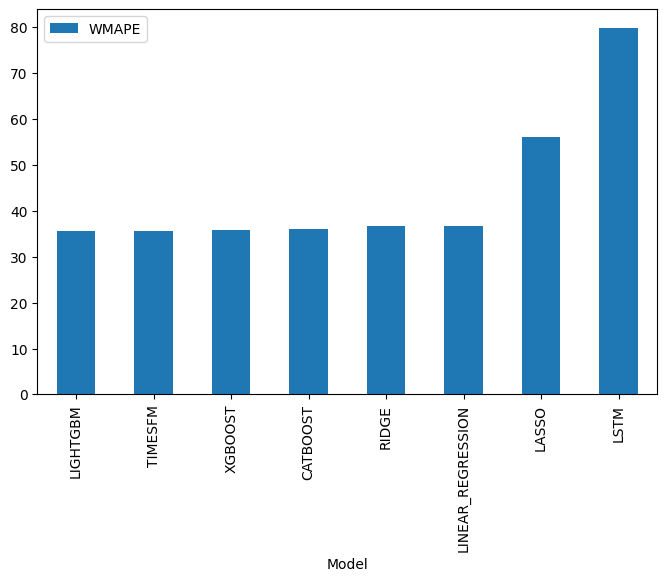

In [24]:
leaderboard_df.sort_values("WMAPE").plot.bar(x="Model", y="WMAPE", figsize=(8,5))

<Axes: xlabel='Model'>

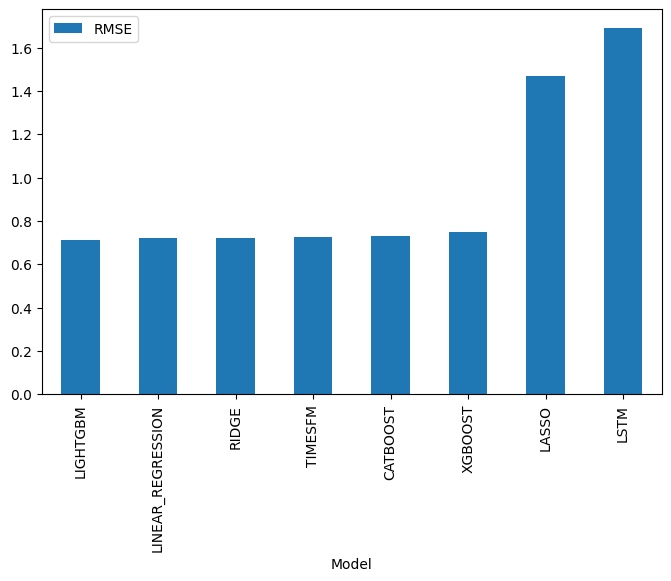

In [25]:
leaderboard_df.sort_values("RMSE").plot.bar(x="Model", y="RMSE", figsize=(8,5))

<Axes: xlabel='Model'>

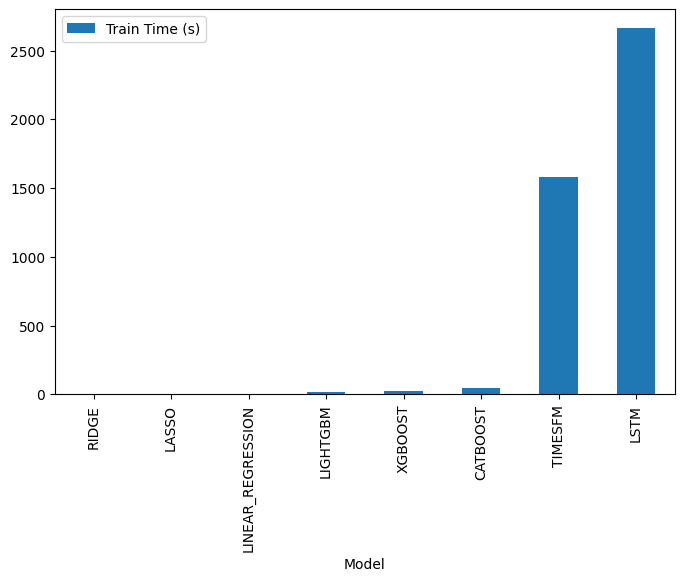

In [26]:
leaderboard_df.sort_values("Train Time (s)").plot.bar(x="Model", y="Train Time (s)", figsize=(8,5))

**Model selection rationale**

Several forecasting models were evaluated, including machine learning algorithms, deep learning models, and the foundation model TimesFM.

Although multiple models achieved competitive forecasting accuracy, **LightGBM** was selected as the final production model because it provides the best trade-off between predictive performance and operational efficiency.

The main reasons are:

- It achieved the best forecasting performance among the evaluated models on the evaluation set.
- Training and inference are significantly faster than deep learning models.
- It naturally supports heterogeneous tabular features, including lag variables, rolling statistics, promotion information, holidays, and weather-related variables.

Therefore, **LightGBM** was chosen as the final model for deployment.

## 9) Best model analysis:

In [27]:
df_train_ready = generate_time_features(df_train_extracted, TARGET, FORECAST_HORIZON)
feature_cols = [col for col in df_train_ready.columns if col not in 
                ['date', TARGET, "product_id", "store_id"]]
train_data = df_train_ready
current_features = feature_cols
model_name = "lightgbm"
run_params = MODEL_PARAMS.get(model_name, {})
artifact = train_unified_model(df_train=train_data, 
                               target_col=TARGET, 
                               feature_cols=current_features, 
                               model_name=model_name, 
                               params=run_params)
y_pred, y_true = predict_unified(artifact, 
                                 df_eval_extracted, 
                                 df_train_extracted, 
                                 current_features, 
                                 TARGET, 
                                 FORECAST_HORIZON,
                                 LOOKBACK_DAYS)

>> [Pipeline] Launch training/initialize architecture: lightgbm
Training the model: LIGHTGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.259262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3623
[LightGBM] [Info] Number of data points in the train set: 4500000, number of used features: 25
[LightGBM] [Info] Start training from score 0.998591
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

### 9.1) Feature importance analysis:

In [28]:
def plot_feature_importance(trained_artifact, feature_cols, model_name, top_k=20):

    model = trained_artifact["model"]

    if model_name in ["linear_regression", "ridge", "lasso"]:

        if hasattr(model, "named_steps"):
            regressor = model.named_steps["regressor"]
            preprocess = model.named_steps["preprocess"]

            feature_names = preprocess.get_feature_names_out()
            importance = np.abs(regressor.coef_)
        else:
            feature_names = feature_cols
            importance = np.abs(model.coef_)

    elif model_name in ["xgboost", "lightgbm"]:

        feature_names = feature_cols
        importance = model.feature_importances_

    elif model_name == "catboost":

        feature_names = feature_cols
        importance = model.get_feature_importance()

    else:

        print(f"{model_name.upper()} does not support feature importance.")
        return

    idx = np.argsort(importance)[::-1][:top_k]

    plt.figure(figsize=(8,6))
    plt.barh(
        np.array(feature_names)[idx][::-1],
        importance[idx][::-1]
    )

    plt.xlabel("Importance")
    plt.title(f"{model_name.upper()} Feature Importance")
    plt.tight_layout()
    plt.show()

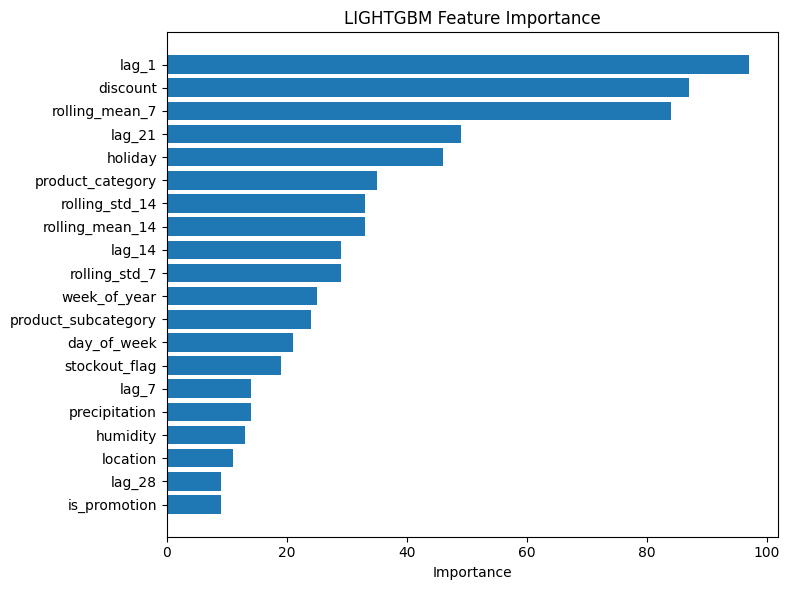

In [29]:
plot_feature_importance(artifact, feature_cols, model_name)

According to the feature importance analysis of the LightGBM model:

- Recent demand history dominates the prediction process, with `lag_1` and `rolling_mean_7` emerging as highly influential features. This suggests that short-term temporal dependencies provide valuable predictive signals for future demand.

- Pricing and calendar-related variables, including `discount` and `holiday`, also contribute to the model's predictions, indicating that they contain useful information beyond historical sales alone. However, feature importance does not establish a causal relationship.

- The relatively high importance of `lag_21` suggests that longer historical observations are useful to the model. Additional autocorrelation or seasonal analysis would be required to confirm whether this represents a genuine three-week demand cycle.

### 9.2) Residual analysis:

In [30]:
def plot_residual_analysis(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    fig, ax = plt.subplots(figsize=(7,5))

    ax.scatter(y_pred, residuals, alpha=0.4)

    ax.axhline(y=0, color="red", linestyle="--")

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(f"{model_name.upper()}'s residual analysis")

    plt.tight_layout()
    plt.show()

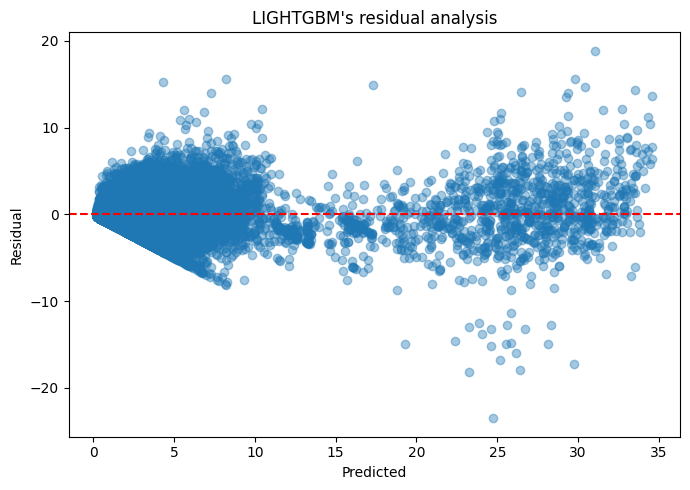

In [31]:
plot_residual_analysis(y_true, y_pred, model_name)

In [32]:
def plot_residual_distribution(y_true, y_pred, model_name):

    residuals = y_true - y_pred
    plt.figure(figsize=(7,5))

    plt.hist(residuals, bins=40)

    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name.upper()}'s residual distribution")
    plt.tight_layout()
    plt.show()

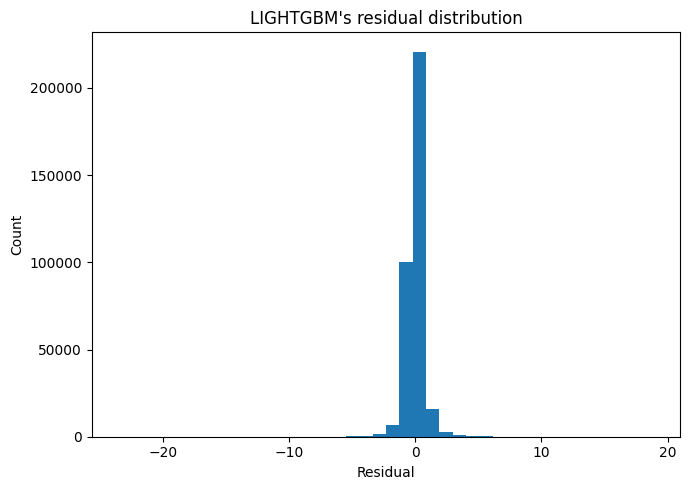

In [33]:
plot_residual_distribution(y_true, y_pred, model_name)

- The residual distribution is concentrated around zero, indicating that many predictions have relatively small errors. However, the concentration should also be interpreted in the context of the large proportion of low-demand observations.

- The residual scatter plot exhibits increasing variance at higher predicted values. This suggests that the model performs more consistently for low-volume observations but has greater uncertainty during high-demand periods.

### 9.3) Actual vs Predicted:

In [34]:
def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.3)

    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())

    plt.plot([low, high], [low, high], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name.upper()} actual vs predicted")
    plt.tight_layout()
    plt.show()

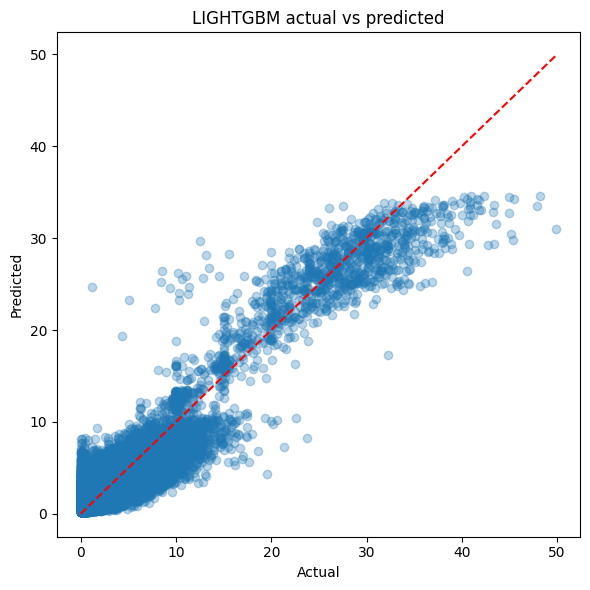

In [35]:
plot_actual_vs_predicted(y_true, y_pred, model_name)

### 9.4) Forecast visualization:

In [36]:
def plot_forecast(df_eval, y_true, y_pred, model_name):

    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="Actual")

    plt.plot(y_pred, label="Prediction")
    plt.legend()
    plt.title(f"{model_name.upper()}'s forecast")
    plt.tight_layout()
    plt.show()

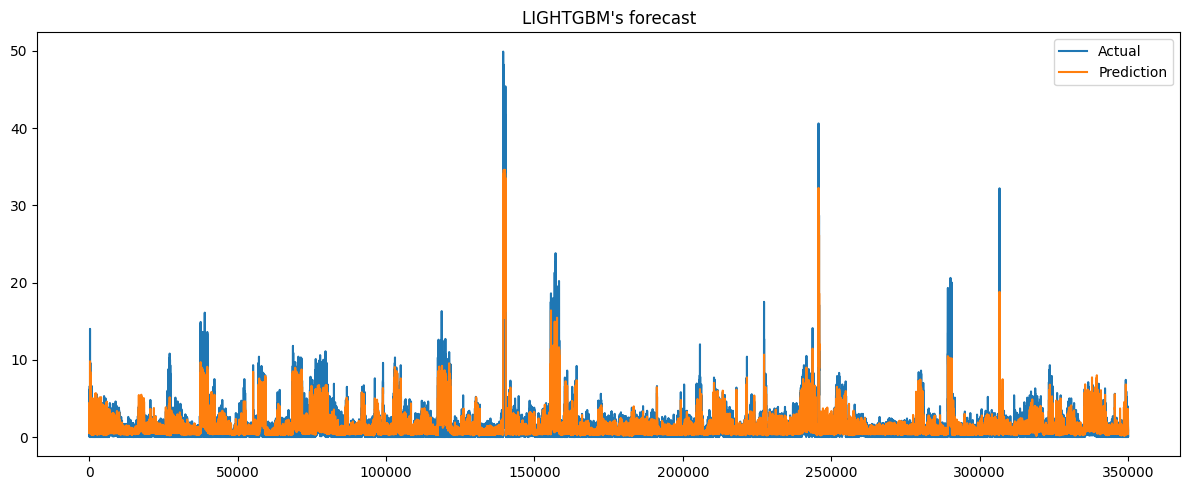

In [37]:
plot_forecast(df_eval, y_true, y_pred, model_name)

## 10) Load model:

In [38]:
def load_unified_model(model_name, save_dir="saved_models"):
    """
    Load a previously saved model and its metadata.
    """

    model_folder = os.path.join(save_dir, model_name)

    if not os.path.exists(model_folder):
        raise FileNotFoundError(f"Cannot find model folder: {model_folder}")

    # Load metadata
    metadata_path = os.path.join(model_folder, "metadata.joblib")

    if not os.path.exists(metadata_path):
        raise FileNotFoundError("metadata.joblib not found.")

    metadata = joblib.load(metadata_path)

    model_type = metadata["model_type"]

    
    # Tabular models
    if model_type == "tabular":

        model = joblib.load(os.path.join(model_folder, "model.joblib"))

        trained_artifact = {"model": model, "type": "tabular"}

    # LSTM
    elif model_type == "deep_learning":
        model = tf.keras.models.load_model(os.path.join(model_folder, "model.keras"))
        trained_artifact = {
            "model": model,
            "scaler": metadata["scaler"],
            "sequence_length": metadata["sequence_length"],
            "type": "deep_learning",
        }

    # TimesFM
    elif model_type == "genai":
        model = initialize_timesfm_model(context_len=metadata["context_length"],
                                         horizon_len=metadata["forecast_horizon"])

        trained_artifact = {"model": model, "type": "genai"}

    else:
        raise ValueError(f"Unknown model type: {model_type}")

    print(f"Loaded {model_name.upper()} successfully!")

    artifact = {**trained_artifact, "metadata": metadata}
    return artifact

## 11) Inference demo:

In [39]:
candidate_models = ["linear_regression", "ridge", "lasso", "xgboost", "lightgbm", "catboost", "lstm", "timesfm"]
pipeline_results = []

for model_name in candidate_models:
    trained_artifact = load_unified_model(model_name)
    current_features = trained_artifact["metadata"]["feature_cols"]
    forecast_horizon = trained_artifact["metadata"]["forecast_horizon"]
    lookback_days = trained_artifact["metadata"]["lookback_days"]
    
    if model_name == "timesfm":         
        current_features = None
        
    start = time.time()
    # Implement the prediction function on the evaluation set
    y_pred, y_true = predict_unified(
        trained_artifact, 
        df_eval_extracted, 
        df_train_extracted, 
        current_features, 
        TARGET, 
        forecast_horizon,
        lookback_days
    )

    inference_time = time.time() - start
    
    # Calculate the evaluation metrics.
    if len(y_true) > 0:
        metrics = evaluate_forecast(y_true, y_pred, model_name)
        metrics['Model'] = model_name.upper()
        metrics["Inference Time (s)"] = round(inference_time,3)
        pipeline_results.append(metrics)
    else:
        print(f"[{model_name.upper()}] Not enough data points in eval set after sequence lookback.")

leaderboard_df = pd.DataFrame(pipeline_results)[['Model', 'WMAPE', 'RMSE', 'Inference Time (s)']]

print("\nOVERALL RANKING")
display(leaderboard_df.sort_values(by="WMAPE").reset_index(drop=True))

Loaded LINEAR_REGRESSION successfully!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: LINEAR_REGRESSION
RMSE  : 0.72
WMAPE : 36.76%
----------------------------------------
Loaded RIDGE successfully!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: RIDGE
RMSE  : 0.72
WMAPE : 36.76%
----------------------------------------
Loaded LASSO successfully!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: LASSO
RMSE  : 1.47
WMAPE : 56.05%
----------------------------------------
Loaded XGBOOST successfully!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATION RESULTS: XGBOOST
RMSE  : 0.75
WMAPE : 35.71%
----------------------------------------
Loaded LIGHTGBM successfully!
Extracting 34 historical dates for buffering...
----------------------------------------
EVALUATIO

,Model,WMAPE,RMSE,Inference Time (s)
0,LIGHTGBM,35.507911,0.712781,52.294
1,TIMESFM,35.572060,0.728645,5083.939
2,XGBOOST,35.706078,0.751817,53.327
3,CATBOOST,36.097771,0.729503,52.780
4,RIDGE,36.761650,0.722217,53.817
5,LINEAR_REGRESSION,36.761651,0.722217,53.075
6,LASSO,56.046044,1.470590,52.223
7,LSTM,79.798874,1.691744,51.195


#### Model Evaluation Summary:

- LightGBM was selected as the final production model because it achieved the lowest error rates (WMAPE: 35.52, RMSE: 0.71). Additionally, it boasts one of the fastest training times and an inference time of approximately 53.3 seconds.
- TimesFM delivers highly competitive accuracy (ranking second), but its massive inference time of over 5,200 seconds (~1.5 hours) makes it less suitable for real-time inference in the current setting.

## 12) Model serving demo with FastAPI:

**FastAPI model serving demo**

The API loads the serialized LightGBM model and exposes a `/predict` endpoint for real-time demand forecasting.

Workflow:

```mermaid
flowchart LR
    A[Client request]
    B["POST /predict"]
    C[FastAPI server]
    D[Feature engineering]
    E[Load trained LightGBM model]
    F[Prediction]
    G[Forecast response]

    A --> B --> C --> D --> E --> F --> G

```

**Abbreviated request example**

Example request

```json
{
  "product_id": 38,
  "store_id": 0,
  "forecast_date": "2024-07-10",
  "product_category": 2,
  "product_subcategory": 17,
  "location": 1,
  "is_promotion": 1,
  "discount": 0.9,
  "holiday": 0,
  "activity_flag": 1,
  "temperature": 29.5,
  "humidity": 78,
  "precipitation": 2.4,
  "wind": 2,
  "history": [
      {
        "date": "2024-06-01",
        "units_ordered": 5.2,
        "discount": 1.0,
        "is_promotion": 0,
        "holiday": 0,
        "activity_flag": 0,
        "temperature": 29.1,
        "humidity": 78.0,
        "precipitation": 0.0,
        "wind": 2.1,
        "stockout_flag": 0
      },
      {
        "date": "2024-06-02",
        "units_ordered": 8.4,
        "discount": 0.8,
        "is_promotion": 1,
        "holiday": 1,
        "activity_flag": 1,
        "temperature": 30.2,
        "humidity": 75.0,
        "precipitation": 1.5,
        "wind": 2.5,
        "stockout_flag": 0
      }
    ]
}
```

Response

```json
{
    "product_id": 38,
    "store_id": 0,
    "forecast_date": "2024-07-10",
    "forecast_horizon": 7,
    "predicted_units": 3.82
}
```

> The request below is abbreviated for readability. A valid request must
> include at least 34 consecutive daily historical observations so that
> all lag and rolling features can be generated.

In [40]:
class HistoricalSale(BaseModel):
    date: date
    units_ordered: float = Field(ge=0)

    discount: float
    is_promotion: int
    holiday: int
    activity_flag: int

    temperature: float
    humidity: float
    precipitation: float
    wind: float

    stockout_flag: int


class ForecastRequest(BaseModel):
    product_id: int
    store_id: int
    forecast_date: date

    product_category: int
    product_subcategory: int
    location: int

    discount: float
    is_promotion: int
    holiday: int
    activity_flag: int = 0

    temperature: float = 0.0
    humidity: float = 0.0
    precipitation: float = 0.0
    wind: float = 0.0

    history: List[HistoricalSale]

In [41]:
def build_inference_features(request: ForecastRequest) -> pd.DataFrame:

    if len(request.history) < LOOKBACK_DAYS:
        raise ValueError(f"At least {LOOKBACK_DAYS} historical observations are required, but only {len(request.history)} were provided.")

    history_df = pd.DataFrame([item.model_dump() for item in request.history])

    history_df["date"] = pd.to_datetime(history_df["date"])

    # Add identifiers and static product/store information.
    history_df["product_id"] = request.product_id
    history_df["store_id"] = request.store_id
    history_df["product_category"] = request.product_category
    history_df["product_subcategory"] = request.product_subcategory
    history_df["location"] = request.location

    # Remove duplicated historical dates and sort chronologically.
    history_df = (history_df.drop_duplicates(subset=["product_id", "store_id", "date"], keep="last")
                  .sort_values(["product_id", "store_id", "date"]).reset_index(drop=True))

    # Validate forecast date
    forecast_date = pd.Timestamp(request.forecast_date)

    if history_df["date"].max() >= forecast_date:
        raise ValueError("All historical dates must be earlier than forecast_date.")
        
    expected_latest_history_date = forecast_date - pd.Timedelta(days=FORECAST_HORIZON)

    if history_df["date"].max() < expected_latest_history_date:
        raise ValueError(
            "The supplied history is too old for the requested forecast date. "
            f"The latest required historical date is "
            f"{expected_latest_history_date.date()}."
        )

    expected_dates = pd.date_range(end=history_df["date"].max(), periods=LOOKBACK_DAYS, freq="D")
    missing_dates = expected_dates.difference(history_df["date"])

    if not missing_dates.empty:
        raise ValueError(
            "Historical data must contain continuous daily observations. "
            f"Missing dates include: "
            f"{missing_dates[:5].strftime('%Y-%m-%d').tolist()}"
        )

    # Create the future row
    future_row = pd.DataFrame(
        [{
            "product_id": request.product_id,
            "store_id": request.store_id,
            "date": forecast_date,
            # Unknown target at prediction time.
            "units_ordered": np.nan,

            # Static information.
            "product_category": request.product_category,
            "product_subcategory": request.product_subcategory,
            "location": request.location,

            # Known future covariates for the forecast date.
            "discount": request.discount,
            "is_promotion": request.is_promotion,
            "holiday": request.holiday,
            "activity_flag": request.activity_flag,
            "temperature": request.temperature,
            "humidity": request.humidity,
            "precipitation": request.precipitation,
            "wind": request.wind,
            "stockout_flag": np.nan,
        }]
    )


    # Generate calendar variables from date
    inference_df = pd.concat([history_df, future_row], ignore_index=True)
    inference_df["date"] = pd.to_datetime(inference_df["date"])
    inference_df["day_of_week"] = inference_df["date"].dt.dayofweek
    inference_df["week_of_year"] = inference_df["date"].dt.isocalendar().week.astype(int)
    inference_df["month"] = inference_df["date"].dt.month
    inference_df["year"] = inference_df["date"].dt.year

    # Generate lag and rolling features
    inference_df = generate_time_features(inference_df, target_col=TARGET, forecast_horizon=FORECAST_HORIZON)

    # Return only the requested future row
    forecast_features = inference_df.loc[inference_df["date"].eq(forecast_date)].tail(1).copy()

    if forecast_features.empty:
        raise ValueError("Unable to generate features for the requested forecast date.")

    return forecast_features

In [42]:
app = FastAPI(title="Demand Forecasting API", version="1.0.0")

# Model
model_name = "lightgbm"
artifact = load_unified_model(model_name)
model = artifact["model"]
lightgbm_feature_cols = artifact["metadata"]["feature_cols"]

@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "model": "LightGBM",
        "forecast_horizon": FORECAST_HORIZON,
    }


@app.post("/predict")
def predict_demand(request: ForecastRequest):
    try:
        feature_row = build_inference_features(request)

        X = feature_row[lightgbm_feature_cols].copy()

        for col in CATE_COLS:
            if col in X.columns:
                X[col] = X[col].astype("category")

        numeric_cols = [col for col in lightgbm_feature_cols if col not in CATE_COLS]

        X[numeric_cols] = X[numeric_cols].fillna(0)

        prediction = model.predict(X)[0]
        prediction = max(float(prediction), 0.0)

        return {
            "product_id": request.product_id,
            "store_id": request.store_id,
            "forecast_date": str(request.forecast_date),
            "forecast_horizon": FORECAST_HORIZON,
            "predicted_units": prediction
        }

    except ValueError as exc:
        raise HTTPException(status_code=400, detail=str(exc)) from exc

    except Exception as exc:
        raise HTTPException(status_code=500, detail=f"Prediction failed: {exc}") from exc

Loaded LIGHTGBM successfully!


In [43]:
client = TestClient(app)

health_response = client.get("/health")

print("Status code:", health_response.status_code)
print("Response:", health_response.json())

Status code: 200
Response: {'status': 'healthy', 'model': 'LightGBM', 'forecast_horizon': 7}


**API validation inside the notebook**

Because this implementation is demonstrated entirely within a notebook,
FastAPI's `TestClient` is used to validate the endpoints without starting
an external web server.

In a standalone deployment, the same application could be moved to
`app.py` and started using:

```bash
uvicorn app:app --host 0.0.0.0 --port 8000
```